# Fuzzy C-Means (FCM) Implementation và Thử nghiệm

Notebook này triển khai và thử nghiệm thuật toán Fuzzy C-Means cho bài toán phân loại văn bản.

## 1. Import các thư viện cần thiết

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linear_sum_assignment
import time
import warnings
warnings.filterwarnings('ignore')

# Import custom FCM module
import sys
sys.path.append('../utils/')
from fcm import Dfcm

print("✓ Đã import tất cả thư viện cần thiết!")

✓ Đã import tất cả thư viện cần thiết!


## 2. Load và khám phá dữ liệu

In [3]:
# Load dataset
df = pd.read_csv('Preprocessed Fake Reviews Detection Dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
print(f"\nSample text:")
print(df['text_'].iloc[0][:200])

Dataset shape: (40432, 5)
Columns: ['Unnamed: 0', 'category', 'rating', 'label', 'text_']

Label distribution:
label
CG    20216
OR    20216
Name: count, dtype: int64

Sample text:
love well made sturdi comfort i love veri pretti


## 3. Tiền xử lý dữ liệu

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

# Download NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    print("✓ NLTK data đã sẵn sàng")
except:
    print("⚠ NLTK data download failed, sử dụng basic preprocessing")

def preprocess_text(text):
    """Tiền xử lý văn bản"""
    try:
        # Chuyển về chữ thường
        text = str(text).lower()
        
        # Loại bỏ ký tự đặc biệt và số
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Tokenization
        tokens = word_tokenize(text)
        
        # Loại bỏ stopwords
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]
        
        # Stemming
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(word) for word in tokens]
        
        # Loại bỏ từ quá ngắn
        tokens = [word for word in tokens if len(word) > 2]
        
        return ' '.join(tokens)
    except:
        return str(text)

# Áp dụng preprocessing
print("Đang tiền xử lý dữ liệu...")
df['processed_text'] = df['text_'].apply(preprocess_text)
print("✓ Hoàn thành tiền xử lý!")

✓ NLTK data đã sẵn sàng
Đang tiền xử lý dữ liệu...
✓ Hoàn thành tiền xử lý!


## 4. Tạo features

In [5]:
# Tạo corpus
corpus = df['processed_text'].tolist()

# Tạo TF-IDF features
tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(corpus)
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

# Giảm chiều với SVD
svd = TruncatedSVD(n_components=500, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f"SVD reduced shape: {X_svd.shape}")
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.3f}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['label'])
print(f"Labels: {label_encoder.classes_} -> {label_encoder.transform(label_encoder.classes_)}")

TF-IDF matrix shape: (40432, 3000)
SVD reduced shape: (40432, 500)
Explained variance: 0.557
Labels: ['CG' 'OR'] -> [0 1]


## 5. Chia dữ liệu train/test

In [6]:
# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X_svd, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training labels: {np.bincount(y_train)}")
print(f"Test labels: {np.bincount(y_test)}")

Training set: (32345, 500)
Test set: (8087, 500)
Training labels: [16172 16173]
Test labels: [4044 4043]


## 6. Hàm map cụm với nhãn thực

In [7]:
def map_clusters_to_labels(cluster_labels, true_labels):
    """Map cluster labels với true labels sử dụng Hungarian Algorithm"""
    from sklearn.metrics import confusion_matrix
    
    # Tạo confusion matrix
    cm = confusion_matrix(true_labels, cluster_labels)
    
    # Sử dụng Hungarian Algorithm để tìm mapping tối ưu
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    # Tạo mapping
    mapping = {row_ind[i]: col_ind[i] for i in range(len(row_ind))}
    
    # Map labels
    mapped_labels = np.zeros_like(cluster_labels)
    for cluster_id, true_label in mapping.items():
        mapped_labels[cluster_labels == cluster_id] = true_label
    
    return mapped_labels, mapping, cm

print("✓ Hàm map cụm đã sẵn sàng!")

✓ Hàm map cụm đã sẵn sàng!


## 7. Thử nghiệm FCM với các cấu hình khác nhau

In [8]:
# Định nghĩa các cấu hình FCM
fcm_configs = {
    "FCM (m=1.5)": {
        'n_clusters': 2, 'm': 1.5, 'epsilon': 1e-6, 'max_iter': 2000, 'metric': 'euclidean'
    },
    "FCM (m=2.0)": {
        'n_clusters': 2, 'm': 2.0, 'epsilon': 1e-6, 'max_iter': 2000, 'metric': 'euclidean'
    },
    "FCM (m=2.5)": {
        'n_clusters': 2, 'm': 2.5, 'epsilon': 1e-6, 'max_iter': 2000, 'metric': 'euclidean'
    },
    "FCM (cosine)": {
        'n_clusters': 2, 'm': 2.0, 'epsilon': 1e-6, 'max_iter': 2000, 'metric': 'cosine'
    },
    "FCM (high_iter)": {
        'n_clusters': 2, 'm': 2.0, 'epsilon': 1e-7, 'max_iter': 5000, 'metric': 'euclidean'
    }
}

results = {}

for config_name, params in fcm_configs.items():
    print(f"\n{'='*50}")
    print(f"Testing: {config_name}")
    print(f"Parameters: {params}")
    
    try:
        # Khởi tạo FCM
        fcm_model = Dfcm(**params)
        
        # Training
        start_time = time.time()
        membership, centroids, steps = fcm_model.fit(
            data=X_train, with_u=True, seed=42
        )
        training_time = time.time() - start_time
        
        # Prediction
        start_time = time.time()
        test_membership = fcm_model.update_membership(X_test, centroids)
        cluster_labels = np.argmax(test_membership, axis=1)
        prediction_time = time.time() - start_time
        
        # Map clusters
        mapped_labels, mapping, cm = map_clusters_to_labels(cluster_labels, y_test)
        
        # Tính metrics
        accuracy = accuracy_score(y_test, mapped_labels)
        precision = precision_score(y_test, mapped_labels, average='weighted')
        recall = recall_score(y_test, mapped_labels, average='weighted')
        f1 = f1_score(y_test, mapped_labels, average='weighted')
        
        # Lưu kết quả
        results[config_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'training_time': training_time,
            'prediction_time': prediction_time,
            'steps': steps,
            'confusion_matrix': cm,
            'mapping': mapping
        }
        
        print(f"✓ Training time: {training_time:.2f}s")
        print(f"✓ Prediction time: {prediction_time:.4f}s")
        print(f"✓ Steps to converge: {steps}")
        print(f"✓ Accuracy: {accuracy:.4f}")
        print(f"✓ Precision: {precision:.4f}")
        print(f"✓ Recall: {recall:.4f}")
        print(f"✓ F1-Score: {f1:.4f}")
        
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        results[config_name] = {'error': str(e)}


Testing: FCM (m=1.5)
Parameters: {'n_clusters': 2, 'm': 1.5, 'epsilon': 1e-06, 'max_iter': 2000, 'metric': 'euclidean'}
✓ Training time: 0.46s
✓ Prediction time: 0.0204s
✓ Steps to converge: 6
✓ Accuracy: 0.5028
✓ Precision: 0.5035
✓ Recall: 0.5028
✓ F1-Score: 0.4756

Testing: FCM (m=2.0)
Parameters: {'n_clusters': 2, 'm': 2.0, 'epsilon': 1e-06, 'max_iter': 2000, 'metric': 'euclidean'}
✓ Training time: 0.37s
✓ Prediction time: 0.0142s
✓ Steps to converge: 5
✓ Accuracy: 0.5029
✓ Precision: 0.5037
✓ Recall: 0.5029
✓ F1-Score: 0.4768

Testing: FCM (m=2.5)
Parameters: {'n_clusters': 2, 'm': 2.5, 'epsilon': 1e-06, 'max_iter': 2000, 'metric': 'euclidean'}
✓ Training time: 0.35s
✓ Prediction time: 0.0131s
✓ Steps to converge: 5
✓ Accuracy: 0.5029
✓ Precision: 0.5037
✓ Recall: 0.5029
✓ F1-Score: 0.4766

Testing: FCM (cosine)
Parameters: {'n_clusters': 2, 'm': 2.0, 'epsilon': 1e-06, 'max_iter': 2000, 'metric': 'cosine'}
✓ Training time: 124.31s
✓ Prediction time: 0.0169s
✓ Steps to converge: 2

## 8. So sánh kết quả các cấu hình

In [9]:
# Tạo bảng so sánh
comparison_data = []
for config_name, result in results.items():
    if 'error' not in result:
        comparison_data.append({
            'Configuration': config_name,
            'Accuracy': f"{result['accuracy']:.4f}",
            'Precision': f"{result['precision']:.4f}",
            'Recall': f"{result['recall']:.4f}",
            'F1-Score': f"{result['f1']:.4f}",
            'Training Time (s)': f"{result['training_time']:.2f}",
            'Prediction Time (s)': f"{result['prediction_time']:.4f}",
            'Steps': result['steps']
        })

if comparison_data:
    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + "="*80)
    print("SO SÁNH HIỆU SUẤT CÁC CẤU HÌNH FCM")
    print("="*80)
    print(comparison_df.to_string(index=False))
else:
    print("❌ Không có kết quả nào để so sánh")


SO SÁNH HIỆU SUẤT CÁC CẤU HÌNH FCM
  Configuration Accuracy Precision Recall F1-Score Training Time (s) Prediction Time (s)  Steps
    FCM (m=1.5)   0.5028    0.5035 0.5028   0.4756              0.46              0.0204      6
    FCM (m=2.0)   0.5029    0.5037 0.5029   0.4768              0.37              0.0142      5
    FCM (m=2.5)   0.5029    0.5037 0.5029   0.4766              0.35              0.0131      5
   FCM (cosine)   0.5001    0.2501 0.5001   0.3334            124.31              0.0169   2000
FCM (high_iter)   0.5033    0.5042 0.5033   0.4760              0.57              0.0149      6


## 9. Visualize kết quả

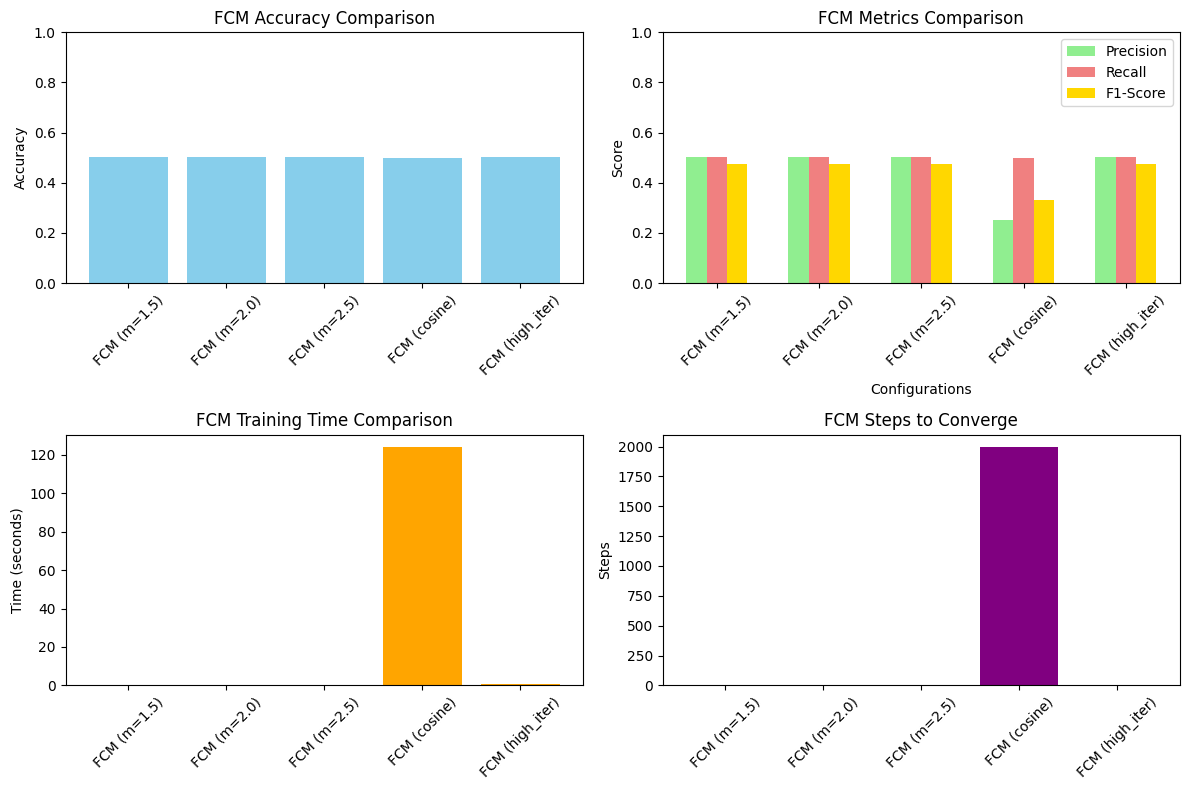

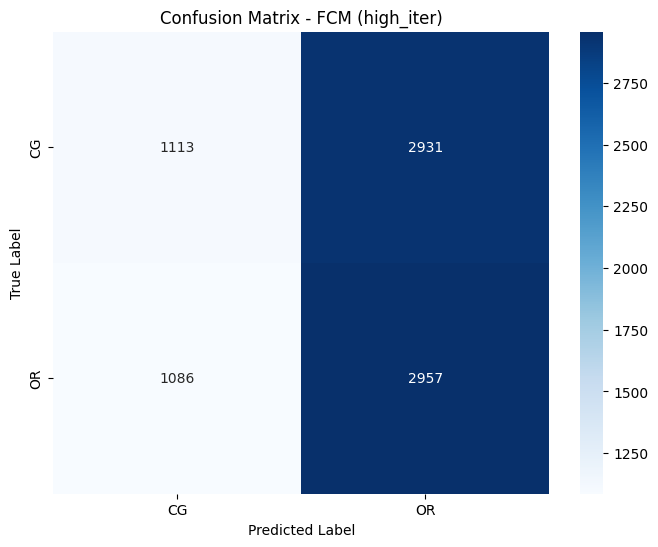

In [10]:
# Vẽ biểu đồ so sánh accuracy
if comparison_data:
    plt.figure(figsize=(12, 8))
    
    # Accuracy comparison
    plt.subplot(2, 2, 1)
    configs = [item['Configuration'] for item in comparison_data]
    accuracies = [float(item['Accuracy']) for item in comparison_data]
    plt.bar(configs, accuracies, color='skyblue')
    plt.title('FCM Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    # Metrics comparison
    plt.subplot(2, 2, 2)
    x = np.arange(len(configs))
    width = 0.2
    
    plt.bar(x - width, [float(item['Precision']) for item in comparison_data], 
            width, label='Precision', color='lightgreen')
    plt.bar(x, [float(item['Recall']) for item in comparison_data], 
            width, label='Recall', color='lightcoral')
    plt.bar(x + width, [float(item['F1-Score']) for item in comparison_data], 
            width, label='F1-Score', color='gold')
    
    plt.xlabel('Configurations')
    plt.ylabel('Score')
    plt.title('FCM Metrics Comparison')
    plt.xticks(x, configs, rotation=45)
    plt.legend()
    plt.ylim(0, 1)
    
    # Training time comparison
    plt.subplot(2, 2, 3)
    training_times = [float(item['Training Time (s)']) for item in comparison_data]
    plt.bar(configs, training_times, color='orange')
    plt.title('FCM Training Time Comparison')
    plt.ylabel('Time (seconds)')
    plt.xticks(rotation=45)
    
    # Steps to converge
    plt.subplot(2, 2, 4)
    steps = [item['Steps'] for item in comparison_data]
    plt.bar(configs, steps, color='purple')
    plt.title('FCM Steps to Converge')
    plt.ylabel('Steps')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Vẽ confusion matrix cho cấu hình tốt nhất
    best_config = max(comparison_data, key=lambda x: float(x['Accuracy']))
    best_config_name = best_config['Configuration']
    
    if best_config_name in results and 'confusion_matrix' in results[best_config_name]:
        plt.figure(figsize=(8, 6))
        cm = results[best_config_name]['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=label_encoder.classes_, 
                    yticklabels=label_encoder.classes_)
        plt.title(f'Confusion Matrix - {best_config_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

## 10. Thử nghiệm FCM với Multiple Runs


THỬ NGHIỆM MULTIPLE RUNS VỚI CẤU HÌNH TỐT NHẤT
Configuration: FCM (high_iter)
Parameters: {'n_clusters': 2, 'm': 2.0, 'epsilon': 1e-07, 'max_iter': 5000, 'metric': 'euclidean'}
Run 1: Accuracy = 0.5011, Steps = 7, Time = 0.83s
Run 2: Accuracy = 0.5003, Steps = 7, Time = 0.74s
Run 3: Accuracy = 0.5004, Steps = 6, Time = 0.74s
Run 4: Accuracy = 0.5008, Steps = 7, Time = 0.66s
Run 5: Accuracy = 0.5002, Steps = 7, Time = 0.69s
Run 6: Accuracy = 0.5011, Steps = 7, Time = 0.52s
Run 7: Accuracy = 0.5006, Steps = 6, Time = 0.46s
Run 8: Accuracy = 0.5023, Steps = 6, Time = 0.46s
Run 9: Accuracy = 0.5003, Steps = 7, Time = 0.56s
Run 10: Accuracy = 0.5009, Steps = 7, Time = 1.10s

Best FCM Accuracy: 0.5023


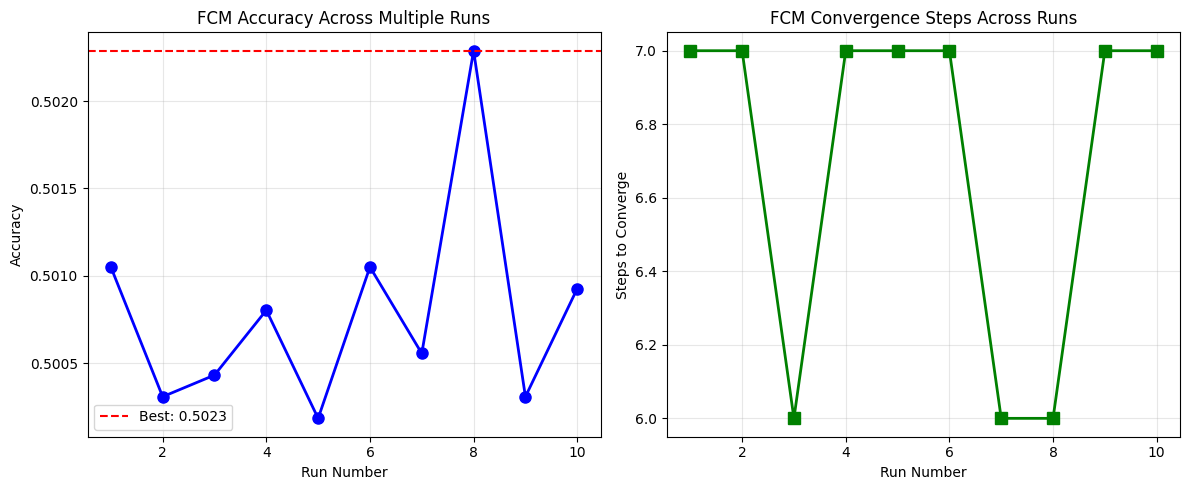

In [11]:
def train_fcm_multiple_runs(X_train, y_train, X_test, n_runs=10, **fcm_params):
    """Train FCM nhiều lần và chọn kết quả tốt nhất"""
    best_accuracy = 0
    best_membership = None
    best_centroids = None
    best_mapping = None
    run_results = []
    
    for run in range(n_runs):
        try:
            # Khởi tạo FCM với seed khác nhau
            fcm_model = Dfcm(**fcm_params)
            
            # Training
            start_time = time.time()
            membership, centroids, steps = fcm_model.fit(
                data=X_train, seed=run, with_u=True
            )
            training_time = time.time() - start_time
            
            # Prediction
            test_membership = fcm_model.update_membership(X_test, centroids)
            cluster_labels = np.argmax(test_membership, axis=1)
            
            # Map clusters
            mapped_labels, mapping, _ = map_clusters_to_labels(cluster_labels, y_test)
            
            # Tính accuracy
            accuracy = accuracy_score(y_test, mapped_labels)
            
            run_results.append({
                'run': run + 1,
                'accuracy': accuracy,
                'steps': steps,
                'training_time': training_time
            })
            
            # Cập nhật kết quả tốt nhất
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_membership = test_membership
                best_centroids = centroids
                best_mapping = mapping
                
            print(f"Run {run+1}: Accuracy = {accuracy:.4f}, Steps = {steps}, Time = {training_time:.2f}s")
            
        except Exception as e:
            print(f"Run {run+1}: Error - {str(e)}")
    
    print(f"\nBest FCM Accuracy: {best_accuracy:.4f}")
    
    return best_membership, best_centroids, best_mapping, best_accuracy, run_results

# Thử nghiệm multiple runs với cấu hình tốt nhất
if comparison_data:
    best_config = max(comparison_data, key=lambda x: float(x['Accuracy']))
    best_config_name = best_config['Configuration']
    
    # Lấy parameters từ cấu hình tốt nhất
    best_params = fcm_configs[best_config_name]
    
    print(f"\n{'='*60}")
    print(f"THỬ NGHIỆM MULTIPLE RUNS VỚI CẤU HÌNH TỐT NHẤT")
    print(f"Configuration: {best_config_name}")
    print(f"Parameters: {best_params}")
    print(f"{'='*60}")
    
    best_membership, best_centroids, best_mapping, best_accuracy, run_results = train_fcm_multiple_runs(
        X_train, y_train, X_test, n_runs=10, **best_params
    )
    
    # Vẽ biểu đồ multiple runs
    if run_results:
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        runs = [item['run'] for item in run_results]
        accuracies = [item['accuracy'] for item in run_results]
        plt.plot(runs, accuracies, 'o-', color='blue', linewidth=2, markersize=8)
        plt.axhline(y=best_accuracy, color='red', linestyle='--', label=f'Best: {best_accuracy:.4f}')
        plt.xlabel('Run Number')
        plt.ylabel('Accuracy')
        plt.title('FCM Accuracy Across Multiple Runs')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        steps = [item['steps'] for item in run_results]
        plt.plot(runs, steps, 's-', color='green', linewidth=2, markersize=8)
        plt.xlabel('Run Number')
        plt.ylabel('Steps to Converge')
        plt.title('FCM Convergence Steps Across Runs')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## 11. Kết luận và đề xuất

In [12]:
print("\n" + "="*80)
print("KẾT LUẬN VÀ ĐỀ XUẤT")
print("="*80)

if comparison_data:
    # Tìm cấu hình tốt nhất
    best_config = max(comparison_data, key=lambda x: float(x['Accuracy']))
    worst_config = min(comparison_data, key=lambda x: float(x['Accuracy']))
    
    print(f"�� Cấu hình tốt nhất: {best_config['Configuration']}")
    print(f"   - Accuracy: {best_config['Accuracy']}")
    print(f"   - Training Time: {best_config['Training Time (s)']}s")
    print(f"   - Steps: {best_config['Steps']}")
    
    print(f"\n⚠️  Cấu hình kém nhất: {worst_config['Configuration']}")
    print(f"   - Accuracy: {worst_config['Accuracy']}")
    
    # Phân tích
    avg_accuracy = np.mean([float(item['Accuracy']) for item in comparison_data])
    print(f"\n�� Phân tích:")
    print(f"   - Accuracy trung bình: {avg_accuracy:.4f}")
    print(f"   - Độ ổn định: {np.std([float(item['Accuracy']) for item in comparison_data]):.4f}")
    
    if avg_accuracy < 0.6:
        print(f"\n💡 Đề xuất cải thiện:")
        print(f"   1. Tăng số features (hiện tại: {X_svd.shape[1]})")
        print(f"   2. Thử nghiệm preprocessing khác")
        print(f"   3. Sử dụng ensemble với supervised models")
        print(f"   4. Thử nghiệm với dữ liệu cân bằng hơn")
    else:
        print(f"\n✅ FCM hoạt động tốt với dataset này!")
else:
    print("❌ Không có kết quả để phân tích")


KẾT LUẬN VÀ ĐỀ XUẤT
�� Cấu hình tốt nhất: FCM (high_iter)
   - Accuracy: 0.5033
   - Training Time: 0.57s
   - Steps: 6

⚠️  Cấu hình kém nhất: FCM (cosine)
   - Accuracy: 0.5001

�� Phân tích:
   - Accuracy trung bình: 0.5024
   - Độ ổn định: 0.0012

💡 Đề xuất cải thiện:
   1. Tăng số features (hiện tại: 500)
   2. Thử nghiệm preprocessing khác
   3. Sử dụng ensemble với supervised models
   4. Thử nghiệm với dữ liệu cân bằng hơn
